**1. Установка необходимых библиотек.**

---



In [ ]:
import nltk
from nltk.corpus import stopwords
import sklearn
import re
import pandas as pd
!pip install keybert
!pip install transformers

**2. Чтение файла и получение информации о нём.**

---



In [ ]:
df = pd.read_csv('/content/sample_data/processed_reviews.csv', index_col=0)
print(df.describe())
print(df.info())
print(df.head(3))

             rate
count  302.000000
mean     4.930464
std      0.421750
min      1.000000
25%      5.000000
50%      5.000000
75%      5.000000
max      5.000000
<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 2026-06-21 to 2026-05-24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    302 non-null    object 
 1   sex     302 non-null    object 
 2   review  250 non-null    object 
 3   rate    302 non-null    float64
 4   market  302 non-null    object 
dtypes: float64(1), object(4)
memory usage: 14.2+ KB
None
                 name      sex                             review  rate  \
create_date                                                               
2026-06-21      Ольга  женский  Достоинства:Всегда беру эту фирму   5.0   
2026-06-21      Алина  женский            Достоинства:Все отлично   5.0   
2026-06-21   Алевтина  женский                                NaN   5.0   

                  market  
cre

In [ ]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
print(df['review'])

create_date
2026-06-21                                                                                                    Достоинства:Всегда беру эту фирму
2026-06-21                                                                                                              Достоинства:Все отлично
2026-06-21                                                                                                                                  NaN
2026-06-21                                                                                               Достоинства:Гель густой,хорошо пенится
2026-06-20    Достоинства:Беру второй раз, очень давольна. Густой, хорошо пенеться. Спасибо большое за качественный товар. Продавца рекомендую.
                                                                            ...                                                                
2026-05-26                                                                                                   Отличный гель. 

In [ ]:
# Валидация значений
# очещаем Nan значения из таблицы в поле 'review'
df = df.dropna(subset=['review'])
total_chars_no_spaces = df['review'].apply(lambda x: len(str(x).replace(' ', ''))).sum()
print(total_chars_no_spaces)

48926


In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 2026-06-21 to 2026-05-24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    250 non-null    object 
 1   sex     250 non-null    object 
 2   review  250 non-null    object 
 3   rate    250 non-null    float64
 4   market  250 non-null    object 
dtypes: float64(1), object(4)
memory usage: 11.7+ KB
None


**3. Предобработка текста**

---



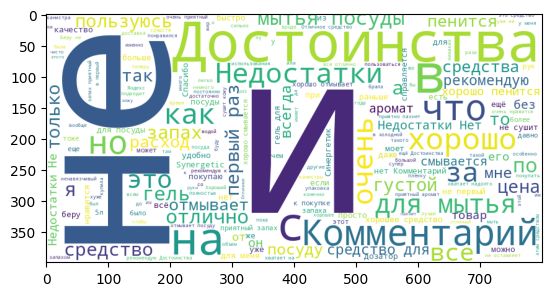

In [ ]:
# облако слов до очистки
import matplotlib.pyplot as plt
from PIL import Image
from wordcloud import WordCloud

merged_text = ' '.join(df['review'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(merged_text)
plt.imshow(wordcloud)


In [ ]:
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
#токенезируем и удаляем стоп-слова
import string

stop_words = set(stopwords.words('russian')) | {'достоинства', 'комментарий', 'недостатки'} - {'не', 'ни', 'нет'}
print(stop_words)
# Множество знаков препинания
punctuation = set(string.punctuation)

def tokenize_and_clean(review):
    if pd.isna(review):
        return []

    tokens = nltk.word_tokenize(review, language='russian')


    tokens_no_punct = [t for t in tokens if t not in punctuation]

    tokens_lower = [t.lower() for t in tokens_no_punct]

    tokens_filtered = [
        t for t in tokens_lower
        if t not in stop_words
    ]
    return tokens_filtered

tokenize_text = [tokenize_and_clean(sentence) for sentence in df['review']]

print(tokenize_text)
print(len(tokenize_text))

{'ничего', 'с', 'вы', 'на', 'нельзя', 'тем', 'этом', 'мой', 'даже', 'при', 'после', 'же', 'то', 'другой', 'разве', 'тогда', 'достоинства', 'до', 'какая', 'что', 'для', 'вас', 'ним', 'его', 'куда', 'недостатки', 'со', 'них', 'к', 'про', 'тоже', 'ну', 'здесь', 'во', 'их', 'сейчас', 'она', 'ее', 'потому', 'только', 'этот', 'хоть', 'по', 'такой', 'я', 'какой', 'все', 'больше', 'более', 'иногда', 'ли', 'ей', 'так', 'есть', 'через', 'лучше', 'хорошо', 'вам', 'чем', 'надо', 'было', 'был', 'теперь', 'опять', 'мы', 'как', 'тебя', 'эти', 'без', 'под', 'почти', 'нее', 'нет', 'но', 'три', 'комментарий', 'мне', 'бы', 'ни', 'тот', 'можно', 'ведь', 'в', 'между', 'наконец', 'или', 'об', 'из', 'еще', 'всего', 'ж', 'меня', 'будет', 'него', 'там', 'вот', 'кто', 'того', 'моя', 'потом', 'два', 'ты', 'ему', 'конечно', 'никогда', 'нибудь', 'себе', 'зачем', 'над', 'будто', 'всех', 'чтобы', 'перед', 'им', 'нас', 'этого', 'а', 'они', 'быть', 'если', 'от', 'были', 'и', 'не', 'где', 'да', 'чтоб', 'он', 'совсем', 

In [ ]:
# лемматизация
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
lemmatized_text = [[lemmatizer.lemmatize(word) for word in sentence] for sentence in tokenize_text]
print(lemmatized_text)

# обединяем токены в предложения
final_text = [" ".join(sentence) for sentence in lemmatized_text]
print(final_text)

[['беру', 'фирму'], ['отлично'], ['гель', 'густой', 'пенится'], ['беру', 'второй', 'очень', 'давольна', 'густой', 'пенеться', 'спасибо', 'большое', 'качественный', 'товар', 'продавца', 'рекомендую'], ['❤️'], ['гель', 'мылится', 'чисто', 'моет', 'посуду', 'запаха'], ['пользуюсь', 'очень', 'нравится', 'рекомендую'], ['отлично', 'отмывает', 'посуду', 'самое', 'главное', 'сушит', 'кожу', 'рук'], ['очень', 'подходит', 'рук'], ['пенится', 'надолго', 'хватает'], ['люблю', 'средства', 'мытья', 'посуды', 'производителя', 'удобная', 'экономичная', 'упаковка', 'цена', 'дорогая'], ['товар', 'упакован', 'гель', 'густой', 'приятно', 'пахнет', 'хватает', 'надолго'], ['объем'], ['сушит', 'руки', 'хорошее', 'средство'], ['хороший', 'гель', 'прекрасно', 'пенится', 'хватает', 'надолго'], ['пользуюсь', 'лет', 'стараюсь', 'изменять', 'оставляет', 'запах', 'самое', 'главное'], ['отличный', 'гель', 'посуды'], ['густой', 'гель', 'бальзам', 'смывает', 'жир', 'плохо'], ['беру', 'первый', 'хватает', 'надолго'], 

In [ ]:
total_chars_clean = sum(len(re.findall(r'\w', text)) for text in final_text)
print(total_chars_clean)

35970


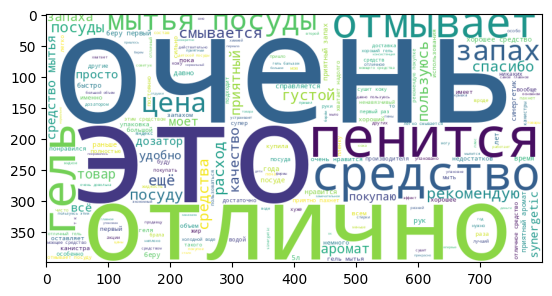

In [ ]:
# облако слов после очистки
merged_text = ' '.join(final_text)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(merged_text)
plt.imshow(wordcloud)

**4. Определение ключевых слов и их значения важности**

---



In [ ]:
from keybert import KeyBERT

# Загружаем модель BERT
model = KeyBERT('DeepPavlov/rubert-base-cased')

# Выводим ключевые слова и коэффициент уверенности модели
keywords = [model.extract_keywords(sentence) for sentence in final_text]
print(keywords)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[[('фирму', 0.6883), ('беру', 0.6802)], [('отлично', 1.0)], [('пенится', 0.7745), ('густой', 0.5847), ('гель', 0.5265)], [('рекомендую', 0.3509), ('беру', 0.2779), ('давольна', 0.2625), ('пенеться', 0.2591), ('спасибо', 0.204)], [], [('мылится', 0.3306), ('моет', 0.3242), ('запаха', 0.292), ('посуду', 0.2779), ('гель', 0.2044)], [('пользуюсь', 0.6742), ('рекомендую', 0.6314), ('нравится', 0.501), ('очень', 0.4139)], [('сушит', 0.2723), ('посуду', 0.2433), ('отмывает', 0.2422), ('главное', 0.2227), ('кожу', 0.2132)], [('подходит', 0.6538), ('очень', 0.6218), ('рук', 0.6083)], [('пенится', 0.7733), ('надолго', 0.5958), ('хватает', 0.575)], [('упаковка', 0.3227), ('экономичная', 0.3219), ('удобная', 0.3078), ('мытья', 0.235), ('дорогая', 0.21)], [('пахнет', 0.3339), ('упакован', 0.2947), ('приятно', 0.1919), ('товар', 0.1912), ('надолго', 0.1868)], [('объем', 1.0)], [('сушит', 0.5794), ('средство', 0.5528), ('хорошее', 0.5516), ('руки', 0.5299)], [('пенится', 0.2992), ('хороший', 0.2212),

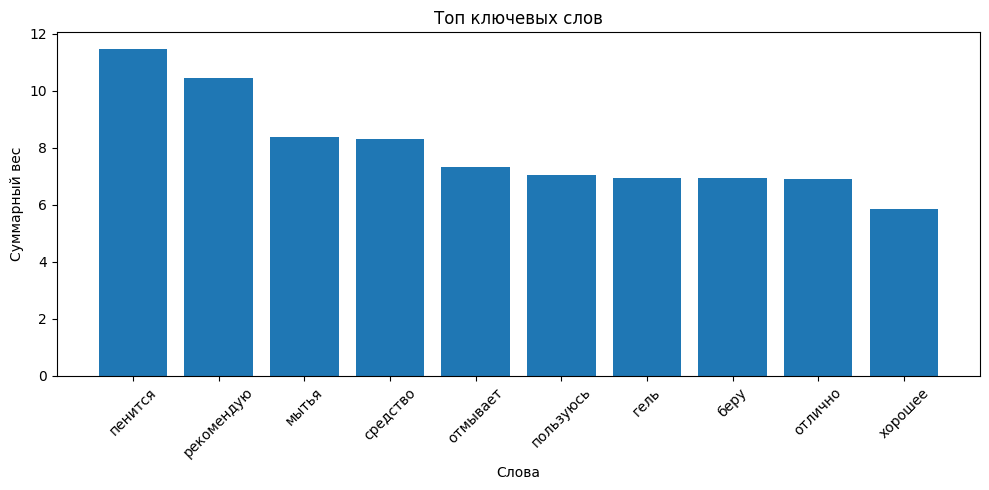

In [ ]:
from collections import defaultdict

word_scores = defaultdict(float)

for review in keywords:
    for word, score in review:
        word_scores[word] += score

top_n = 10

top_words = sorted(
    word_scores.items(),
    key=lambda x: x[1],
    reverse=True
)[:top_n]

words, scores = zip(*top_words)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(words, scores)

plt.xticks(rotation=45)
plt.title("Топ ключевых слов")
plt.xlabel("Слова")
plt.ylabel("Суммарный вес")

plt.tight_layout()
plt.show()

In [ ]:
df['keywords'] = keywords
df

,name,sex,review,rate,market,keywords
create_date,,,,,,
2026-06-21,Ольга,женский,Достоинства:Всегда беру эту фирму,5.0,Wildberries,"[(фирму, 0.6883), (беру, 0.6802)]"
2026-06-21,Алина,женский,Достоинства:Все отлично,5.0,Wildberries,"[(отлично, 1.0)]"
2026-06-21,Сальмахан,мужской,"Достоинства:Гель густой,хорошо пенится",1.0,Wildberries,"[(пенится, 0.7745), (густой, 0.5847), (гель, 0.5265)]"
2026-06-20,Наталья,женский,"Достоинства:Беру второй раз, очень давольна. Густой, хорошо пенеться. Спасибо большое за качественный товар. Продавца рекомендую.",5.0,Wildberries,"[(рекомендую, 0.3509), (беру, 0.2779), (давольна, 0.2625), (пенеться, 0.2591), (спасибо, 0.204)]"
2026-06-20,Покупатель,мужской,Достоинства:❤️,5.0,Wildberries,[]
...,...,...,...,...,...,...
2026-05-26,Николай,мужской,Отличный гель. Не первый раз берем,5.0,Ozon,"[(гель, 0.5521), (первый, 0.5491), (отличный, 0.5392), (берем, 0.4972)]"
2026-05-26,Ольга,женский,"Очень хорошее средство, пенится отлично и доставка быстрая надолго хватит",5.0,Ozon,"[(пенится, 0.2819), (хватит, 0.263), (хорошее, 0.2466), (быстрая, 0.2281), (надолго, 0.2165)]"
2026-05-25,Татьяна,женский,хорошо,5.0,Ozon,[]


**5. Определение тональности отзывов.**

---



In [ ]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="cointegrated/rubert-tiny-sentiment-balanced"
)

def predict(text):
    result = classifier(text)[0]
    return result['label']

df['sentiment'] = df['review'].apply(predict)

config.json:   0%|          | 0.00/884 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/47.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/377 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/241k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/468k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
df

,name,sex,review,rate,market,keywords,sentiment
create_date,,,,,,,
2026-06-21,Ольга,женский,Достоинства:Всегда беру эту фирму,5.0,Wildberries,"[(фирму, 0.6883), (беру, 0.6802)]",neutral
2026-06-21,Алина,женский,Достоинства:Все отлично,5.0,Wildberries,"[(отлично, 1.0)]",positive
2026-06-21,Сальмахан,мужской,"Достоинства:Гель густой,хорошо пенится",1.0,Wildberries,"[(пенится, 0.7745), (густой, 0.5847), (гель, 0.5265)]",positive
2026-06-20,Наталья,женский,"Достоинства:Беру второй раз, очень давольна. Густой, хорошо пенеться. Спасибо большое за качественный товар. Продавца рекомендую.",5.0,Wildberries,"[(рекомендую, 0.3509), (беру, 0.2779), (давольна, 0.2625), (пенеться, 0.2591), (спасибо, 0.204)]",positive
2026-06-20,Покупатель,мужской,Достоинства:❤️,5.0,Wildberries,[],positive
...,...,...,...,...,...,...,...
2026-05-26,Николай,мужской,Отличный гель. Не первый раз берем,5.0,Ozon,"[(гель, 0.5521), (первый, 0.5491), (отличный, 0.5392), (берем, 0.4972)]",positive
2026-05-26,Ольга,женский,"Очень хорошее средство, пенится отлично и доставка быстрая надолго хватит",5.0,Ozon,"[(пенится, 0.2819), (хватит, 0.263), (хорошее, 0.2466), (быстрая, 0.2281), (надолго, 0.2165)]",positive
2026-05-25,Татьяна,женский,хорошо,5.0,Ozon,[],positive


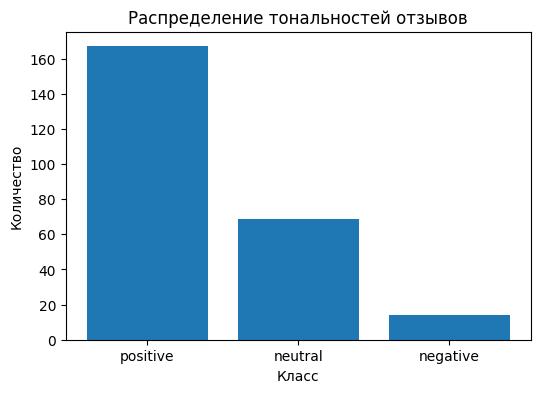

In [ ]:
import matplotlib.pyplot as plt

counts = df['sentiment'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)

plt.title('Распределение тональностей отзывов')
plt.xlabel('Класс')
plt.ylabel('Количество')

plt.show()

**6. Сохранение таблицы в виде csv-файла**

---



In [ ]:
df.to_csv('markets_reviews.csv', index=False)

**7. Оценка точности предсказаний модели метрикой Accuracy**

In [ ]:
from sklearn.metrics import accuracy_score


true_sentiments_df = pd.read_csv('/content/sample_data/true_sentiments.csv')


sentiment_mapping = {
    0: 'positive',
    1: 'negative',
    2: 'neutral'
}

true_sentiments_df['true_sentiment'] = true_sentiments_df.iloc[:, 0].map(sentiment_mapping)

if len(df) != len(true_sentiments_df):
    print("Warning: The number of predicted sentiments does not match the number of true sentiments.")
    print(f"Predicted sentiments count: {len(df)}")
    print(f"True sentiments count: {len(true_sentiments_df)}")

accuracy = accuracy_score(true_sentiments_df['true_sentiment'], df['sentiment'])

print(f"Точность модели: {accuracy:.2f}")

Точность модели: 0.72


**8. Аналитика и графики**

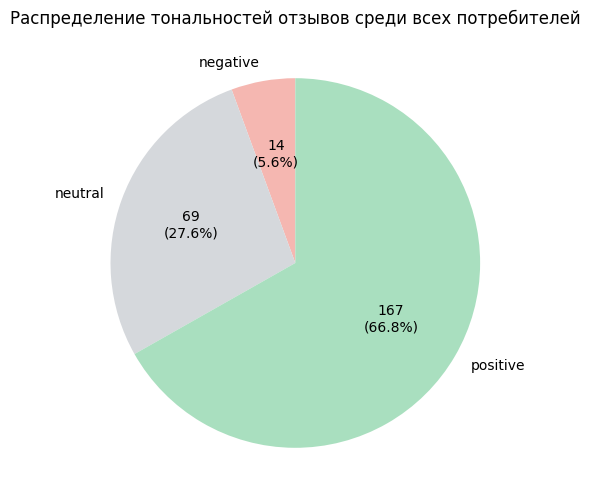

In [ ]:
import matplotlib.pyplot as plt

order = ['negative', 'neutral', 'positive']
counts = df['sentiment'].value_counts().reindex(order).fillna(0)

def autopct_format(values):
    def inner(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{val}\n({pct:.1f}%)'
    return inner

plt.figure(figsize=(6, 6))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct=autopct_format(counts.values),
    startangle=90,
    colors = ['#f5b7b1', '#d5d8dc', '#a9dfbf']
)

plt.title('Распределение тональностей отзывов среди всех потребителей')

plt.show()

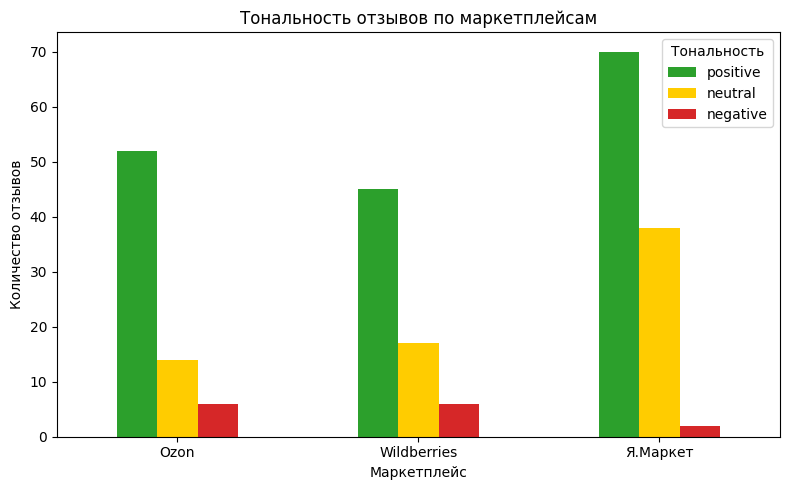

In [ ]:
counts = df.groupby(['market', 'sentiment']).size().unstack(fill_value=0)

ax = counts[['positive', 'neutral', 'negative']].plot(
    kind='bar',
    figsize=(8, 5),
    color=['#2ca02c', '#ffcc00', '#d62728']  # green, yellow, red
)

plt.title('Тональность отзывов по маркетплейсам')
plt.xlabel('Маркетплейс')
plt.ylabel('Количество отзывов')
plt.xticks(rotation=0)
plt.legend(title='Тональность')
plt.tight_layout()
plt.show()

In [ ]:
gender_counts = df['sex'].value_counts()
print(gender_counts)

sex
женский       161
мужской        68
неизвестно     21
Name: count, dtype: int64


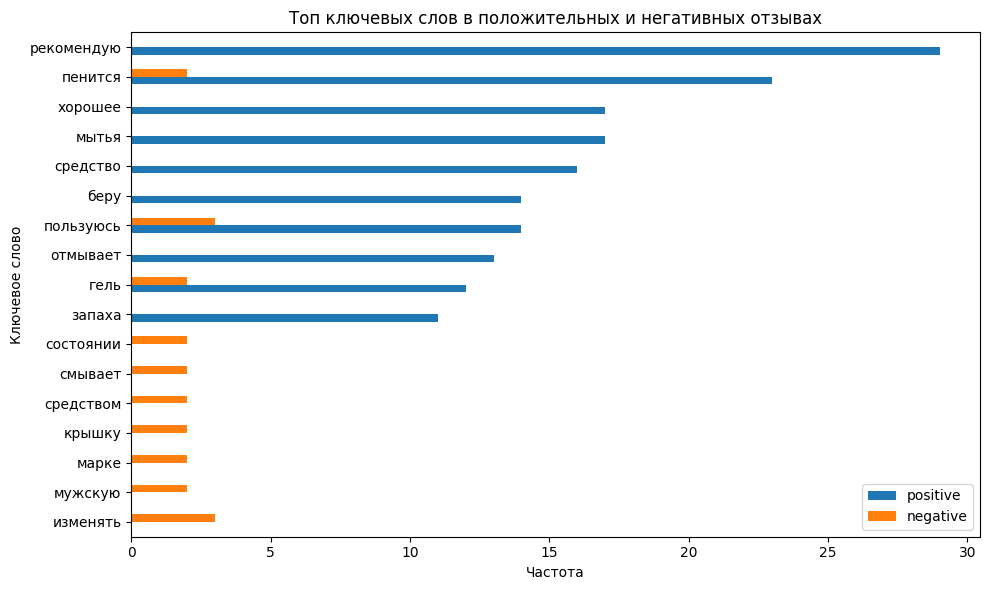

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

def extract_words(s):
    if pd.isna(s):
        return []
    return re.findall(r"'([^']+)'", str(s))

df = pd.read_csv('markets_reviews.csv')
df = df[df['sentiment'].isin(['positive', 'negative'])].copy()
df['words'] = df['keywords'].apply(extract_words)

rows = []
for _, row in df.iterrows():
    for w in row['words']:
        rows.append((row['sentiment'], w.lower().strip()))

kw_df = pd.DataFrame(rows, columns=['sentiment', 'word'])

plot_df = pd.DataFrame({
    'positive': kw_df[kw_df['sentiment'] == 'positive']['word'].value_counts().head(10),
    'negative': kw_df[kw_df['sentiment'] == 'negative']['word'].value_counts().head(10)
}).fillna(0)

plot_df.sort_values('positive').plot(kind='barh', figsize=(10, 6))
plt.title('Топ ключевых слов в положительных и негативных отзывах')
plt.xlabel('Частота')
plt.ylabel('Ключевое слово')
plt.tight_layout()
plt.show()

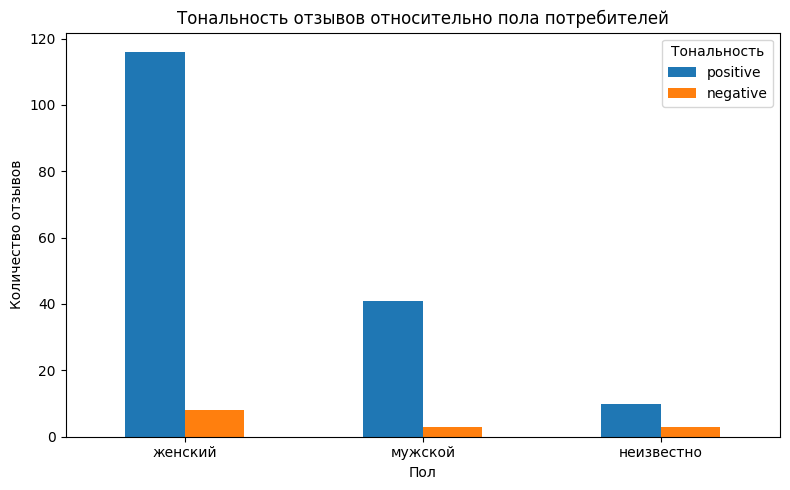

In [ ]:
counts_ = df.groupby(['sex', 'sentiment']).size().unstack(fill_value=0)
counts_[['positive', 'negative']].plot(kind='bar', figsize=(8, 5))

plt.title('Тональность отзывов относительно пола потребителей')
plt.xlabel('Пол')
plt.ylabel('Количество отзывов')
plt.xticks(rotation=0)
plt.legend(title='Тональность')
plt.tight_layout()
plt.show()